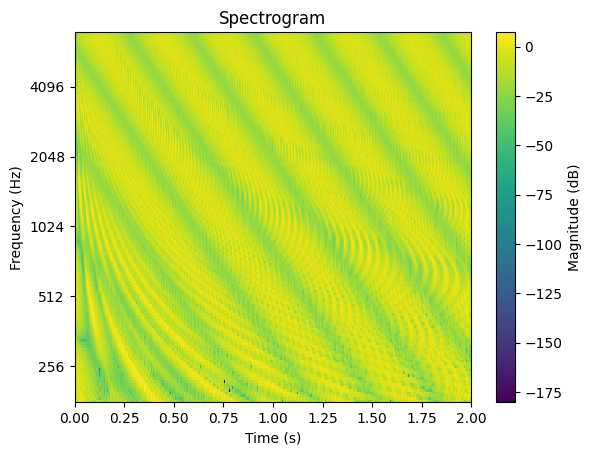

In [2]:
import numpy as np
from mathfuncs import gen_ripple
from visualize_outputs import plot_spectrogram
from neural_audio.wav2aud import wav2aud

half_rates  = 2 ** np.linspace(np.log2(0.5), np.log2(128), 16)   # temporal rates [Hz]
half_scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)    # spectral scales [cyc/oct]
waveform = gen_ripple(rate=half_rates[5], scale=half_scales[5])
time_points, frequencies, audiogram = wav2aud(waveform)

plot_spectrogram(audiogram, time_points, frequencies)

---
## **Directionality of the rates**

The rate axis of `cr` has length `2 * len(rates)`, not `len(rates)`. That doubling is **not** extra rate resolution — it encodes the *direction* in which a spectrotemporal pattern sweeps.

A ripple in the audiogram is a diagonal pattern whose peaks drift across frequency as time passes. It can drift **downward** (energy moving from high to low frequency) or **upward**. Both versions have the same rate in Hz and the same scale in cycles/octave; they differ only in the sign of the drift. A filter tuned to unsigned rate alone could not tell them apart, so `aud2cor` runs every rate filter twice — once per sign — and stores the two results in separate halves of the rate axis:

```python
for sgn in [1, -1]:
    ...
    col = rdx + (num_rates if sgn == 1 else 0)
    cr[sdx, col, :, :] = z
```

- columns `0 .. len(rates)-1` come from the `sgn = -1` branch
- columns `len(rates) .. 2*len(rates)-1` come from the `sgn = +1` branch

Mechanically, the `sgn = +1` branch zero-pads the temporal transfer function so it keeps only positive modulation frequencies, and the `sgn = -1` branch builds its conjugate mirror. Each is therefore blind to one drift direction.

Which *physical* direction each half corresponds to depends on the sign convention of the rate, which is why the docstrings avoid committing to "upward" and "downward" labels. Rather than assert one, the cells below measure it.

##### **Step 1: build two stimuli that differ only in direction**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from neural_audio.wav2aud import wav2aud
from neural_audio.aud2cor import aud2cor
from neural_audio.utils.mathfuncs import gen_ripple
from neural_audio.utils.visualize_outputs import plot_spectrogram

# 8 x 8 keeps each cr around 130 MB; enough resolution to make the point.
dir_rates = 2 ** np.linspace(np.log2(0.5), np.log2(32), 8)    # temporal rates [Hz]
dir_scales = 2 ** np.linspace(np.log2(1/5), np.log2(8), 8)    # spectral scales [cyc/oct]

probe_rate = dir_rates[4]
probe_scale = dir_scales[4]
print(f"rate channels [Hz]: {np.round(dir_rates, 2)}")
print(f"probe ripple: {probe_rate:.1f} Hz, {probe_scale:.1f} cyc/oct")

# gen_ripple's envelope is 1 + sin(2*pi*rate*t + 2*pi*scale*pos), so a point of
# constant phase satisfies pos = -(rate/scale)*t + c: a POSITIVE rate drifts DOWN
# in frequency, a negative rate drifts up.
ripples = {
    "downward (rate > 0)": gen_ripple(rate=+probe_rate, scale=probe_scale, duration=2.0),
    "upward (rate < 0)":   gen_ripple(rate=-probe_rate, scale=probe_scale, duration=2.0),
}

# wav2aud once per stimulus; the cortical cell below reuses these audiograms
audiograms = {name: wav2aud(wave) for name, wave in ripples.items()}

# plot_spectrogram takes no ax argument and draws into the current axes, hence plt.sca
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (tp, fr, aud)) in zip(axes, audiograms.items()):
    plt.sca(ax)
    plot_spectrogram(aud, tp, fr, title=f"Audiogram: {name}")
plt.tight_layout()
plt.show()

##### **Step 2: which half of the rate axis responds?**

The two audiograms above are mirror images: same rate, same scale, opposite tilt. If the doubled rate axis really encodes direction, then each stimulus should light up one half and leave the other comparatively quiet.

To check this, collapse `cr` down to the rate axis alone (averaging over scale, time and frequency) and plot the two halves next to each other on a single **signed** rate axis, with the first half drawn at negative rates.

In [ ]:
# Run each ripple through aud2cor and read off the rate axis.
# The two halves are laid out side by side on a single SIGNED rate axis:
# first half (sgn = -1) is drawn at negative rates, second half (sgn = +1) at positive.
n_rates = len(dir_rates)
signed_rates = np.concatenate([-dir_rates[::-1], dir_rates])
column_order = np.concatenate([np.arange(n_rates)[::-1], np.arange(n_rates) + n_rates])

profiles = {}
for name, (_, _, aud) in audiograms.items():
    cr = aud2cor(aud, rates=dir_rates, scales=dir_scales)
    # collapse everything except the rate axis, then reorder onto the signed axis
    profiles[name] = np.abs(cr).mean(axis=(0, 2, 3))[column_order]
    del cr  # ~130 MB per call, so don't hold both at once

fig, ax = plt.subplots(figsize=(9, 4))
for name, prof in profiles.items():
    ax.plot(range(2 * n_rates), prof, marker="o", label=name)

ax.axvline(n_rates - 0.5, color="grey", ls="--", lw=1)  # boundary between the two halves
ax.set_xticks(range(2 * n_rates))
ax.set_xticklabels([f"{s:+.1f}" for s in signed_rates], rotation=45)
ax.set_xlabel("Rate channel [Hz]  (negative = columns 0..n-1, positive = columns n..2n-1)")
ax.set_ylabel("Mean |cr|")
ax.set_title("Each sweep direction excites one half of the rate axis")
ax.legend(loc="upper center")
plt.tight_layout()
plt.show()

for name, prof in profiles.items():
    k = int(prof.argmax())
    print(f"{name:22s} peak at {signed_rates[k]:+6.2f} Hz   "
          f"peak/mirror = {prof[k] / prof[::-1][k]:.2f}")

##### **Reading the result**

Each stimulus produces a single clear peak, and the two peaks are mirror images of one another:

| stimulus | peak lands at | peak vs. the mirrored channel |
| --- | --- | --- |
| downward ripple (`rate > 0`) | `+5.4 Hz`, i.e. the **second** half | 4.8x |
| upward ripple (`rate < 0`) | `-5.4 Hz`, i.e. the **first** half | 3.2x |

So for this sign convention, **the second half of the rate axis (`sgn = +1`) responds to downward sweeps and the first half (`sgn = -1`) to upward sweeps.** Note also that only the matching half peaks at the correct rate channel; the other half has no coherent peak at all, which is what distinguishes a genuine directional match from leakage.

The selectivity is a ratio of about 3-5x rather than an on/off switch. That is expected: the cochlear filters ring, and a 2 s stimulus contains onset and offset transients that are not directional, so both halves always carry some energy.

> **Why this is invisible in `plot_cr_projection`.** `cr_projections` begins by averaging the two halves together:
> ```python
> cr_avgr = ((np.abs(cr[:, :n_rate]) + np.abs(cr[:, n_rate:2 * n_rate])) / 2).mean(axis=2)
> ```
> Direction is deliberately collapsed there so that the panels are comparable across stimuli. To see direction you have to slice the halves yourself, as above, or pass a single half to `plot_cr_temporal` (its docstring shows this).

**Open question for the tutorial draft:** whether this belongs in Tutorial 2 (next to *Rates and scales*, since it is a property of the output layout) or in Tutorial 3 (next to `gen_ripple`, since it needs a directional stimulus to demonstrate). It reads better in Tutorial 3, but Tutorial 2 is where a reader first meets `num_rates * 2` and would be confused by it.

---
## **Physical meaning of the positive and negative rates**

The section above established *where* direction lives in `cr`. This one is about what that sign corresponds to in an actual sound.

##### **What the sign encodes**

The sign of the rate is the **direction of the spectrotemporal sweep**: whether the pattern of energy migrates toward higher or toward lower frequencies as time passes. Magnitude and sign answer two different questions:

| quantity | question it answers |
| --- | --- |
| `abs(rate)` (Hz) | how *fast* the pattern moves |
| `sign(rate)` | which *way* it moves |
| `scale` (cyc/oct) | how *finely* it is patterned across frequency |

The figure below plots the ideal ripple envelope directly from its definition, with no cochlear filtering in the way, so the two directions are unambiguous.

##### **Why it has to be represented separately**

An upward and a downward sweep of the same rate and scale are clearly different sounds, yet they are **indistinguishable** by either of the two descriptions one would normally reach for:

- the **long-term power spectrum** is the same for both, since each contains the same frequencies for the same total time;
- the **unsigned modulation content** is the same too, since both modulate at the same rate in Hz and the same scale in cycles/octave.

Direction survives in neither. It is genuinely extra information, and the only way to keep it is to give every rate two filters — which is precisely what the doubled rate axis is for. The audio players below make the point better than the figures do: the two stimuli are built from an identical set of carriers at identical amplitudes, and still sound different.

##### **Where it shows up in real sounds**

- **Speech.** Formant trajectories glide into and out of consonants, and the direction of the second-formant transition is one of the classic cues distinguishing consonants that precede the same vowel. A representation blind to direction discards it.
- **Animal vocalisations.** Birdsong and many mammalian calls are largely assembled from up- and down-chirps, where direction is often what separates one call type from another.
- **Everyday sounds.** Anything with a glide — a passing siren, an engine revving, a zip being pulled — carries much of its identity in which way the glide runs.

##### **Why the model bothers**

Neurons in primary auditory cortex are direction-selective: many respond considerably more strongly to one sweep direction than to the other. The cortical model reproduces this by running each rate filter in both signs (Chi et al., 2005), so the asymmetry is carried in the representation rather than averaged out of it.

This is worth keeping in mind when reducing `cr` for analysis. Natural sounds are not symmetric in sweep direction, so collapsing the two halves — which is the first thing `cr_projections` does — discards a dimension along which real sounds genuinely differ. That is a reasonable trade for a summary figure, and a poor one for anything meant to characterise what a sound *is*.

> **Reminder on convention.** Which sign corresponds to which physical direction depends on the sign convention of the rate vector *and* on how the stimulus was generated. The previous section measured it for this setup; if either changes, measure it again rather than assuming it carried over.

In [ ]:
from IPython.display import Audio, display

# The ideal ripple envelope, drawn straight from its definition. No cochlear
# filtering is involved, so the geometry of the sweep is completely unobscured
# (compare with the audiograms above, where the filters blur it).
t_grid = np.linspace(0, 1.0, 400)
oct_grid = np.linspace(0, np.log2(7040 / 180), 300)   # gen_ripple's default carrier span
T, O = np.meshgrid(t_grid, oct_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, sgn, name in zip(axes, [+1, -1], ["rate > 0: sweeps DOWN", "rate < 0: sweeps UP"]):
    envelope = 1 + np.sin(2 * np.pi * sgn * probe_rate * T + 2 * np.pi * probe_scale * O)
    ax.pcolormesh(t_grid, oct_grid, envelope, shading="auto", cmap="viridis")
    ax.set_title(f"{name}   ({sgn * probe_rate:+.1f} Hz)")
    ax.set_xlabel("Time (s)")
axes[0].set_ylabel("Octaves above 180 Hz")
plt.tight_layout()
plt.show()

# The same two stimuli, to listen to. Identical spectra, identical |rate| and
# scale -- the only difference is which way the pattern glides.
for name, wave in ripples.items():
    print(name)
    display(Audio(wave, rate=16000))

---
## **Plotting directionality: only `plot_cr_temporal` can do it**

The two sections above sliced the rate axis by hand. Of the two plotting helpers in `visualize_outputs`, only one will accept such a slice — and the difference is visible in how each validates its input.

**`plot_cr_projection` cannot.** It requires both directions and rejects anything else outright:

```python
if cr.shape[1] != 2 * len(rates):
    raise ValueError(f"cr.shape[1] ({cr.shape[1]}) must equal 2*len(rates) ({2*len(rates)}).")
```

and even for accepted input, `cr_projections` averages the two halves as its first step. So it is direction-blind by construction, not by accident: passing a single half raises, and passing the whole thing collapses the distinction.

**`plot_cr_temporal` can.** It branches on the width of the rate axis:

```python
if cr.shape[1] == 2 * n_rate:
    mag = (np.abs(cr[:, :n_rate]) + np.abs(cr[:, n_rate:2 * n_rate])) / 2   # averaged
elif cr.shape[1] == n_rate:
    mag = np.abs(cr)                                                        # used as-is
```

Passing one half together with the **full** `rates` vector takes the second branch, and the rate ticks still label correctly because that half has one column per rate. Its docstring documents this usage explicitly.

The cell below plots both halves of a single downward ripple, one direction per row, using the `axes` argument to place all four panels in one figure. What to look for:

| row | strongest rate channel | peak value |
| --- | --- | --- |
| first half (`sgn = -1`) | 17.67 Hz — no band at the stimulus rate | 0.036 |
| second half (`sgn = +1`) | **5.38 Hz** — a sustained band, matching the stimulus | 0.127 |

The matching half also recovers the scale cleanly (a steady band at ~1.6 cyc/oct in its Scale-Time panel), while the non-matching half shows only scattered high-rate energy.

> **Careful with the colour scale.** `plot_cr_temporal` calls `imshow` with no `vmin`/`vmax`, so every panel self-normalises and the weaker half would render just as bright as the stronger one — the same trap as the time-averaged projection. The cell fixes each column to a shared scale afterwards. Without that step the figure looks like both directions respond equally, which is the opposite of the truth.

cr_down (8, 16, 500, 128)  ->  each half is (8, 8, 500, 128)
plot_cr_projection refuses a single direction -> cr.shape[1] (8) must equal 2*len(rates) (16).


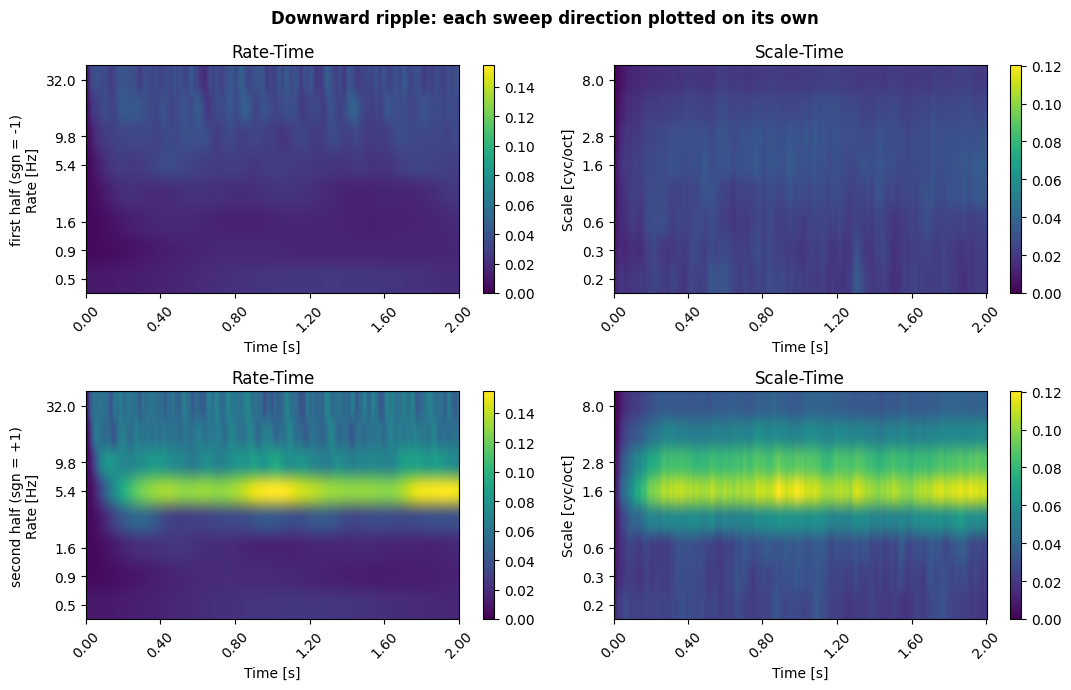

first half (sgn = -1)    strongest rate channel = 17.67 Hz   peak = 0.0356
second half (sgn = +1)   strongest rate channel =  5.38 Hz   peak = 0.1272


In [ ]:
from neural_audio.utils.visualize_outputs import plot_cr_projection, plot_cr_temporal

# One cortical representation, kept this time so both halves can be sliced out of it.
tp_down, _, aud_down = audiograms["downward (rate > 0)"]
cr_down = aud2cor(aud_down, rates=dir_rates, scales=dir_scales)
print(f"cr_down {cr_down.shape}  ->  each half is {cr_down[:, :n_rates].shape}")

# plot_cr_projection cannot be asked for one direction: it validates the rate axis
# against 2*len(rates) and averages the halves regardless.
try:
    plot_cr_projection(cr_down[:, :n_rates], dir_rates, scales=dir_scales)
except ValueError as err:
    print(f"plot_cr_projection refuses a single direction -> {err}")

# pass one half at a time to plot only one direction
halves = {
    "first half (sgn = -1)": cr_down[:, :n_rates],
    "second half (sgn = +1)": cr_down[:, n_rates:],
}

fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for row, (name, half) in zip(axs, halves.items()):
    plot_cr_temporal(half, dir_rates, scales=dir_scales, time_points=tp_down, axes=row)
    row[0].set_ylabel(f"{name}\nRate [Hz]")

# plot_cr_temporal auto-scales every panel, which would make both directions look as if they
# respond equally, which is not the case. Put each column on a shared scale instead.
for col in range(2):
    ims = [axs[row, col].images[0] for row in range(2)]
    vmax = max(im.get_array().max() for im in ims)
    for im in ims:
        im.set_clim(0, vmax)

fig.suptitle("Downward ripple: each sweep direction plotted on its own", fontweight="bold")
fig.tight_layout()
plt.show()

for name, half in halves.items():
    prof = np.abs(half).mean(axis=(0, 2, 3))
    k = int(prof.argmax())
    print(f"{name:24s} strongest rate channel = {dir_rates[k]:5.2f} Hz   peak = {prof[k]:.4f}")

del cr_down 